<a href="https://colab.research.google.com/github/Avinash-Tamarapalli/Machine-Learning/blob/feature%2Fml-learn/Linear%20Regression/ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Linear Regression

## Importing Life Expectancy Dataset from WHO

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'life-expectancy-who' dataset.
Path to dataset files: /kaggle/input/life-expectancy-who


In [ ]:
import os

files_only = []

for item in os.listdir(path):
    full_path = os.path.join(path, item)
    if os.path.isfile(full_path):
        files_only.append(full_path)

print("Only files with full paths:")
for file_path in files_only:
    print(file_path)


Only files with full paths:
/kaggle/input/life-expectancy-who/.nfs00000000854e96d300000097
/kaggle/input/life-expectancy-who/Life Expectancy Data.csv


In [ ]:
import pandas as pd

life = pd.read_csv("/kaggle/input/life-expectancy-who/Life Expectancy Data.csv")

life.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df = life

## Exploring the Life Expectancy Dataset.

### 1. The Structural Audit

In [ ]:
# Dimensionality Check:
df.shape

(2938, 22)

In [ ]:
#Data Type Validation:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [ ]:
# Applying the strip first as you intended
df.columns = df.columns.str.strip()

# Defining the mapping (added the HDI suggestion)
new_cols = {
    "Country": "country",
    "Year": "year",
    "Status": "status",
    "Life expectancy": "life_expectancy",
    "Adult Mortality": "adult_mortality",
    "infant deaths": "infant_mortality",
    "Alcohol": "alcohol_consumption",
    "percentage expenditure": "percent_health_expenditure",
    "Hepatitis B": "hepB_immune_coverage",
    "Measles": "measles_cases",
    "BMI": "avg_bmi",
    "under-five deaths": "under_five_mortality",
    "Polio": "pol3_immune_coverage",
    "Total expenditure": "percent_gov_health_expenditure",
    "Diphtheria" : "DTP3_immune_coverage",
    "HIV/AIDS" : "hiv_mortality",
    "GDP": "gdp",
    "Population": "population",
    "thinness  1-19 years": "thinness_1_19_years",
    "thinness 5-9 years": "thinness_5_9_years",
    "Income composition of resources": "hdi", # Suggested: Human Development Index
    "Schooling": "schooling_years"
}

# Execute the rename
df = df.rename(columns=new_cols)

# Quick check
print(df.columns)

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_mortality', 'alcohol_consumption', 'percent_health_expenditure',
       'hepB_immune_coverage', 'measles_cases', 'avg_bmi',
       'under_five_mortality', 'pol3_immune_coverage',
       'percent_gov_health_expenditure', 'DTP3_immune_coverage',
       'hiv_mortality', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'hdi', 'schooling_years'],
      dtype='object')


In [ ]:
# To get the count of nulls per column
print(df.isnull().sum())

country                             0
year                                0
status                              0
life_expectancy                    10
adult_mortality                    10
infant_mortality                    0
alcohol_consumption               194
percent_health_expenditure          0
hepB_immune_coverage              553
measles_cases                       0
avg_bmi                            34
under_five_mortality                0
pol3_immune_coverage               19
percent_gov_health_expenditure    226
DTP3_immune_coverage               19
hiv_mortality                       0
gdp                               448
population                        652
thinness_1_19_years                34
thinness_5_9_years                 34
hdi                               167
schooling_years                   163
dtype: int64


### 2. Handling Null Values

In [ ]:
# To get the percent of nulls per column
null_percent = df.isnull().mean() * 100
print(null_percent.tail())

population             22.191967
thinness_1_19_years     1.157250
thinness_5_9_years      1.157250
hdi                     5.684139
schooling_years         5.547992
dtype: float64


In [ ]:
null_percent = df.isnull().mean() * 100
null_percent_threshold = 0.5
null_with_threshold = null_percent[null_percent > null_percent_threshold]

columns = list(null_with_threshold.index)

null_df = df.loc[:, columns]

null_df.head()

,alcohol_consumption,hepB_immune_coverage,avg_bmi,pol3_immune_coverage,percent_gov_health_expenditure,DTP3_immune_coverage,gdp,population,thinness_1_19_years,thinness_5_9_years,hdi,schooling_years
0,0.01,65.0,19.1,6.0,8.16,65.0,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0.01,62.0,18.6,58.0,8.18,62.0,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0.01,64.0,18.1,62.0,8.13,64.0,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0.01,67.0,17.6,67.0,8.52,67.0,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0.01,68.0,17.2,68.0,7.87,68.0,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
def get_null_columns(df, threshold= 0.5):
  # Create a summary Series
  null_summary = df.isnull().mean() * 100

  # Filter for columns above the threshold
  high_null_cols = null_summary[null_summary > threshold].sort_values(ascending=False)

  return high_null_cols

print("Columns to investigate:")
print(get_null_columns(df, 0.5))

Columns to investigate:
population                        22.191967
hepB_immune_coverage              18.822328
gdp                               15.248468
percent_gov_health_expenditure     7.692308
alcohol_consumption                6.603131
hdi                                5.684139
schooling_years                    5.547992
avg_bmi                            1.157250
thinness_1_19_years                1.157250
thinness_5_9_years                 1.157250
pol3_immune_coverage               0.646698
DTP3_immune_coverage               0.646698
dtype: float64


After placing a null threshold of *0.5%*, We got the above columns as that has major null that needed to be handled column by column

In [ ]:
df[df.columns[df.isnull().mean() * 100 > 0.5]].head()

,alcohol_consumption,hepB_immune_coverage,avg_bmi,pol3_immune_coverage,percent_gov_health_expenditure,DTP3_immune_coverage,gdp,population,thinness_1_19_years,thinness_5_9_years,hdi,schooling_years
0,0.01,65.0,19.1,6.0,8.16,65.0,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0.01,62.0,18.6,58.0,8.18,62.0,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0.01,64.0,18.1,62.0,8.13,64.0,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0.01,67.0,17.6,67.0,8.52,67.0,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0.01,68.0,17.2,68.0,7.87,68.0,63.537231,2978599.0,18.2,18.2,0.454,9.5


#### population

The Total Population of each country

In [ ]:
print(df['population'].describe())

count    2.286000e+03
mean     1.275338e+07
std      6.101210e+07
min      3.400000e+01
25%      1.957932e+05
50%      1.386542e+06
75%      7.420359e+06
max      1.293859e+09
Name: population, dtype: float64


Here we can observe that mean is *12.7 M* and median is *1.3 M*.
Since the mean is skewed to the positive side and filling them with mean doesn't give any honest representation.

We can also observe that 75% is *7.4 M* which is closer to the mean, meaning there are some country with huge population on the top 10-20% which is the skewing the mean towards the positive side.

Hence for Population we replace the nulls with ***median***

In [ ]:
df.loc[:,['population']] = df['population'].fillna(value= df['population'].median())

print(get_null_columns(df, 0.5))

hepB_immune_coverage              18.822328
gdp                               15.248468
percent_gov_health_expenditure     7.692308
alcohol_consumption                6.603131
hdi                                5.684139
schooling_years                    5.547992
avg_bmi                            1.157250
thinness_5_9_years                 1.157250
thinness_1_19_years                1.157250
DTP3_immune_coverage               0.646698
pol3_immune_coverage               0.646698
dtype: float64


#### hepB_immune_coverage

Hepatitis B (HepB) immunization coverage among 1-year-olds (%)

In [ ]:
print(df.loc[:,['hepB_immune_coverage']].describe())

       hepB_immune_coverage
count           2385.000000
mean              80.940461
std               25.070016
min                1.000000
25%               77.000000
50%               92.000000
75%               97.000000
max               99.000000


Here the mean is *80.9* and median is *92*. Hence we can use mean to fill the NaN values.

In [ ]:
df.loc[:,['hepB_immune_coverage']] = df.loc[:,['hepB_immune_coverage']].fillna(value= df['hepB_immune_coverage'].mean())
print(get_null_columns(df, 0.5))

gdp                               15.248468
percent_gov_health_expenditure     7.692308
alcohol_consumption                6.603131
hdi                                5.684139
schooling_years                    5.547992
avg_bmi                            1.157250
thinness_5_9_years                 1.157250
thinness_1_19_years                1.157250
DTP3_immune_coverage               0.646698
pol3_immune_coverage               0.646698
dtype: float64


#### gdp

Gross Domestic Product (GDP) of each country

In [ ]:
print(df['gdp'].describe())

count      2490.000000
mean       7483.158469
std       14270.169342
min           1.681350
25%         463.935626
50%        1766.947595
75%        5910.806335
max      119172.741800
Name: gdp, dtype: float64


Here also mean is positively skewed. Hence using median

In [ ]:
df.loc[:, ['gdp']] = df['gdp'].fillna(df['gdp'].median())

print(get_null_columns(df))

percent_gov_health_expenditure    7.692308
alcohol_consumption               6.603131
hdi                               5.684139
schooling_years                   5.547992
avg_bmi                           1.157250
thinness_5_9_years                1.157250
thinness_1_19_years               1.157250
DTP3_immune_coverage              0.646698
pol3_immune_coverage              0.646698
dtype: float64


#### percent_gov_health_expenditure
Expenditure on health as a percentage of Gross Domestic Product per capita(%)

In [ ]:
print(df['percent_gov_health_expenditure'].describe())

count    2712.00000
mean        5.93819
std         2.49832
min         0.37000
25%         4.26000
50%         5.75500
75%         7.49250
max        17.60000
Name: percent_gov_health_expenditure, dtype: float64


Here also we can replace NaN values with mean.

In [ ]:
df.loc[:, ["percent_gov_health_expenditure"]] = df["percent_gov_health_expenditure"].fillna(df["percent_gov_health_expenditure"].mean())

print(get_null_columns(df))

alcohol_consumption     6.603131
hdi                     5.684139
schooling_years         5.547992
avg_bmi                 1.157250
thinness_5_9_years      1.157250
thinness_1_19_years     1.157250
DTP3_immune_coverage    0.646698
pol3_immune_coverage    0.646698
dtype: float64


#### alcohol_consumption

Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)

In [ ]:
print(df['alcohol_consumption'].describe())

count    2744.000000
mean        4.602861
std         4.052413
min         0.010000
25%         0.877500
50%         3.755000
75%         7.702500
max        17.870000
Name: alcohol_consumption, dtype: float64


Here also we will fill NaN with mean

In [ ]:
df.loc[:, ["alcohol_consumption"]] = df["alcohol_consumption"].fillna(df['alcohol_consumption'].mean())

print(get_null_columns(df))

hdi                     5.684139
schooling_years         5.547992
avg_bmi                 1.157250
thinness_5_9_years      1.157250
thinness_1_19_years     1.157250
DTP3_immune_coverage    0.646698
pol3_immune_coverage    0.646698
dtype: float64


#### hdi

Expenditure on health as a percentage of Gross Domestic Product per capita(%)

In [ ]:
print(df['hdi'].describe())

count    2771.000000
mean        0.627551
std         0.210904
min         0.000000
25%         0.493000
50%         0.677000
75%         0.779000
max         0.948000
Name: hdi, dtype: float64


In [ ]:
df.loc[:, ["hdi"]] = df["hdi"].fillna(df["hdi"].mean())

print(get_null_columns(df))

schooling_years         5.547992
avg_bmi                 1.157250
thinness_5_9_years      1.157250
thinness_1_19_years     1.157250
pol3_immune_coverage    0.646698
DTP3_immune_coverage    0.646698
dtype: float64


#### schooling_years

Number of years of Schooling(years)

In [ ]:
print(df["schooling_years"].describe())

count    2775.000000
mean       11.992793
std         3.358920
min         0.000000
25%        10.100000
50%        12.300000
75%        14.300000
max        20.700000
Name: schooling_years, dtype: float64


In [ ]:
df.loc[:, ["schooling_years"]] = df["schooling_years"].fillna(df["schooling_years"].mean())

print(get_null_columns(df))

avg_bmi                 1.157250
thinness_5_9_years      1.157250
thinness_1_19_years     1.157250
DTP3_immune_coverage    0.646698
pol3_immune_coverage    0.646698
dtype: float64


#### avg_bmi

Average Body Mass Index of entire population

In [ ]:
print(df["avg_bmi"].describe())

count    2904.000000
mean       38.321247
std        20.044034
min         1.000000
25%        19.300000
50%        43.500000
75%        56.200000
max        87.300000
Name: avg_bmi, dtype: float64


In [ ]:
df.loc[:, ["avg_bmi"]] = df["avg_bmi"].fillna(df["avg_bmi"].median())

print(get_null_columns(df))

thinness_5_9_years      1.157250
thinness_1_19_years     1.157250
DTP3_immune_coverage    0.646698
pol3_immune_coverage    0.646698
dtype: float64


#### thinness_5_9_years

Prevalence of thinness among children for Age 5 to 9 (%)

In [ ]:
print(df["thinness_5_9_years"].describe())

count    2904.000000
mean        4.870317
std         4.508882
min         0.100000
25%         1.500000
50%         3.300000
75%         7.200000
max        28.600000
Name: thinness_5_9_years, dtype: float64


In [ ]:
df.loc[:, ["thinness_5_9_years"]] = df["thinness_5_9_years"].fillna(df["thinness_5_9_years"].median())

print(get_null_columns(df))

thinness_1_19_years     1.157250
pol3_immune_coverage    0.646698
DTP3_immune_coverage    0.646698
dtype: float64


#### thinness_1_19_years

Prevalence of thinness among children and adolescents for Age 10 to 19 (%)

In [ ]:
print(df["thinness_1_19_years"].describe())

count    2904.000000
mean        4.839704
std         4.420195
min         0.100000
25%         1.600000
50%         3.300000
75%         7.200000
max        27.700000
Name: thinness_1_19_years, dtype: float64


In [ ]:
df.loc[:, ["thinness_1_19_years"]] = df["thinness_1_19_years"].fillna(df["thinness_1_19_years"].median())

print(get_null_columns(df))

pol3_immune_coverage    0.646698
DTP3_immune_coverage    0.646698
dtype: float64


#### pol3_immune_coverage

Polio (Pol3) immunization coverage among 1-year-olds (%)

In [ ]:
print(df["pol3_immune_coverage"].describe())

count    2919.000000
mean       82.550188
std        23.428046
min         3.000000
25%        78.000000
50%        93.000000
75%        97.000000
max        99.000000
Name: pol3_immune_coverage, dtype: float64


In [ ]:
df.loc[:, ["pol3_immune_coverage"]] = df["pol3_immune_coverage"].fillna(df["pol3_immune_coverage"].mean())

print(get_null_columns(df))

DTP3_immune_coverage    0.646698
dtype: float64


#### DTP3_immune_coverage

Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)*italicised text*

### 3. Univariate Analysis

In [ ]:
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_mortality', 'alcohol_consumption', 'percent_health_expenditure',
       'hepB_immune_coverage', 'measles_cases', 'avg_bmi',
       'under_five_mortality', 'pol3_immune_coverage',
       'percent_gov_health_expenditure', 'DTP3_immune_coverage',
       'hiv_mortality', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'hdi', 'schooling_years'],
      dtype='object')

#### 1. Country

In [ ]:
print(df["country"].describe())

count            2938
unique            193
top       Afghanistan
freq               16
Name: country, dtype: object


In [ ]:
print(df["schooling_years"].describe())

count    2938.000000
mean       11.992793
std         3.264381
min         0.000000
25%        10.300000
50%        12.100000
75%        14.100000
max        20.700000
Name: schooling_years, dtype: float64


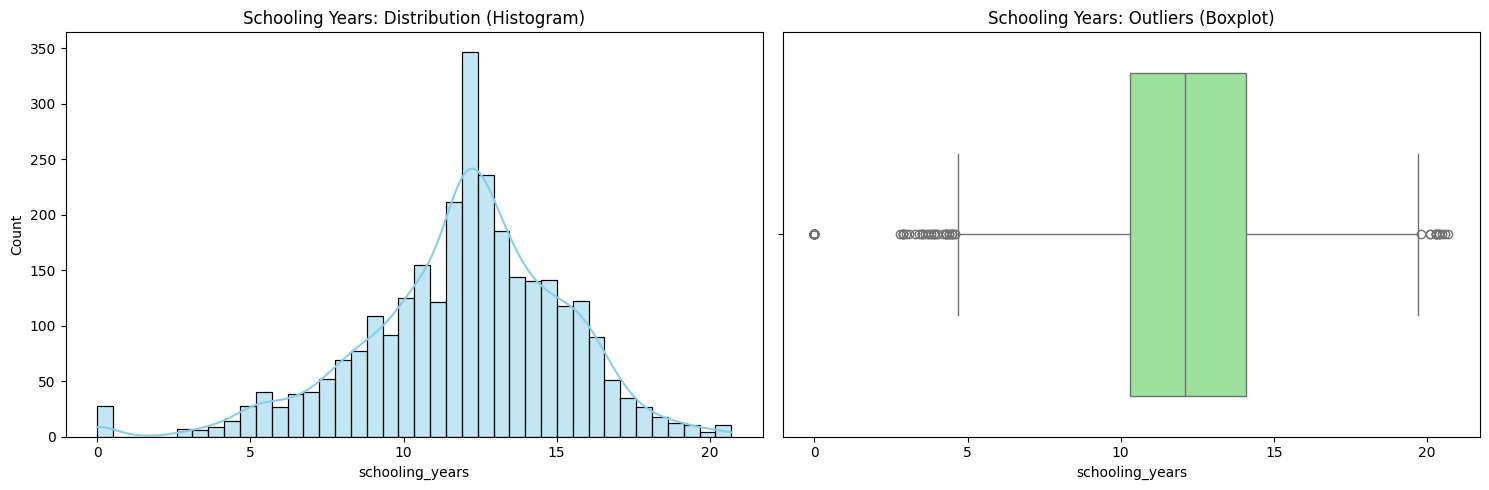

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram + KDE (Kernel Density Estimate)
# This shows the "shape" and symmetry of the data
sns.histplot(df['schooling_years'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Schooling Years: Distribution (Histogram)')

# 2. Boxplot
# This highlights the Median (middle line) and Outliers (dots outside the whiskers)
sns.boxplot(x=df['schooling_years'], ax=axes[1], color='lightgreen')
axes[1].set_title('Schooling Years: Outliers (Boxplot)')

plt.tight_layout()
plt.show()

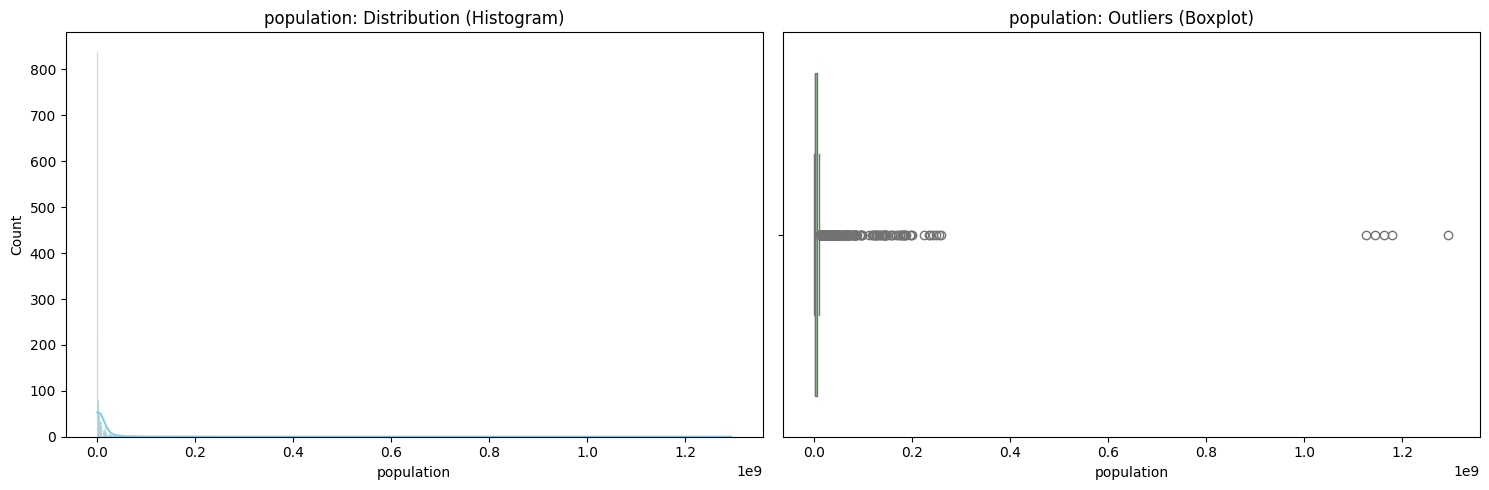

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram + KDE (Kernel Density Estimate)
# This shows the "shape" and symmetry of the data
sns.histplot(df['population'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('population: Distribution (Histogram)')

# 2. Boxplot
# This highlights the Median (middle line) and Outliers (dots outside the whiskers)
sns.boxplot(x=df['population'], ax=axes[1], color='lightgreen')
axes[1].set_title('population: Outliers (Boxplot)')

plt.tight_layout()
plt.show()